In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
import json

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.style.use('default')


In [2]:
sensor_display = {45: 'M1', 48: 'M2'}
def display_sensor(s):
    return sensor_display.get(s, s)

Analysis was split into two files to avoid excessive clutter. This file concerns itself with the early statistical analysis of both sensor datasets and early exploration.

# Statistical Analysis

As the collection of data was conducted separately from this study, control of the quality of the data is limited to post-collection. To do so, a thorough analysis of each dataset is conducted to find missing data, inconsistencies etc. This step ensures the validity of the data, and provides first insight into the municipality's process of data collection.

In [3]:
df_CityAI = pd.read_csv("CityAI_data.csv")
df_Munisense = pd.read_csv("Munisense_data.csv")

In [4]:
df_CityAI = df_CityAI.drop("Unnamed: 0", axis=1)
df_Munisense = df_Munisense.drop("Unnamed: 0", axis=1)

In [5]:
print(len(df_CityAI))
print(len(df_Munisense))

1511442
172800


In [6]:
print(len(df_CityAI)/len(df_CityAI["sensor"].unique()))
print(len(df_Munisense)/len(df_Munisense["sensor"].unique()))

167938.0
172800.0


In [7]:
print(df_CityAI.info())
print(df_Munisense.info())


<class 'pandas.DataFrame'>
RangeIndex: 1511442 entries, 0 to 1511441
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   sensor    1511442 non-null  int64  
 1   datetime  1511442 non-null  str    
 2   date      1511442 non-null  str    
 3   time      1511442 non-null  str    
 4   dba       1511442 non-null  float64
 5   avg_spla  1511442 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 122.5 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 172800 entries, 0 to 172799
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   sensor    172800 non-null  int64  
 1   datetime  172800 non-null  str    
 2   date      172800 non-null  str    
 3   time      172800 non-null  str    
 4   dba       172800 non-null  float64
 5   avg_spla  172800 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 14.0 MB
None


### Missing values

In [8]:
print(df_CityAI.groupby("sensor")["dba"].count())
print(df_Munisense.groupby("sensor")["dba"].count())

sensor
2     170493
3     169115
4     172360
5     170703
6     172473
7     162675
9     167310
11    168956
12    157357
Name: dba, dtype: int64
sensor
45    172800
Name: dba, dtype: int64


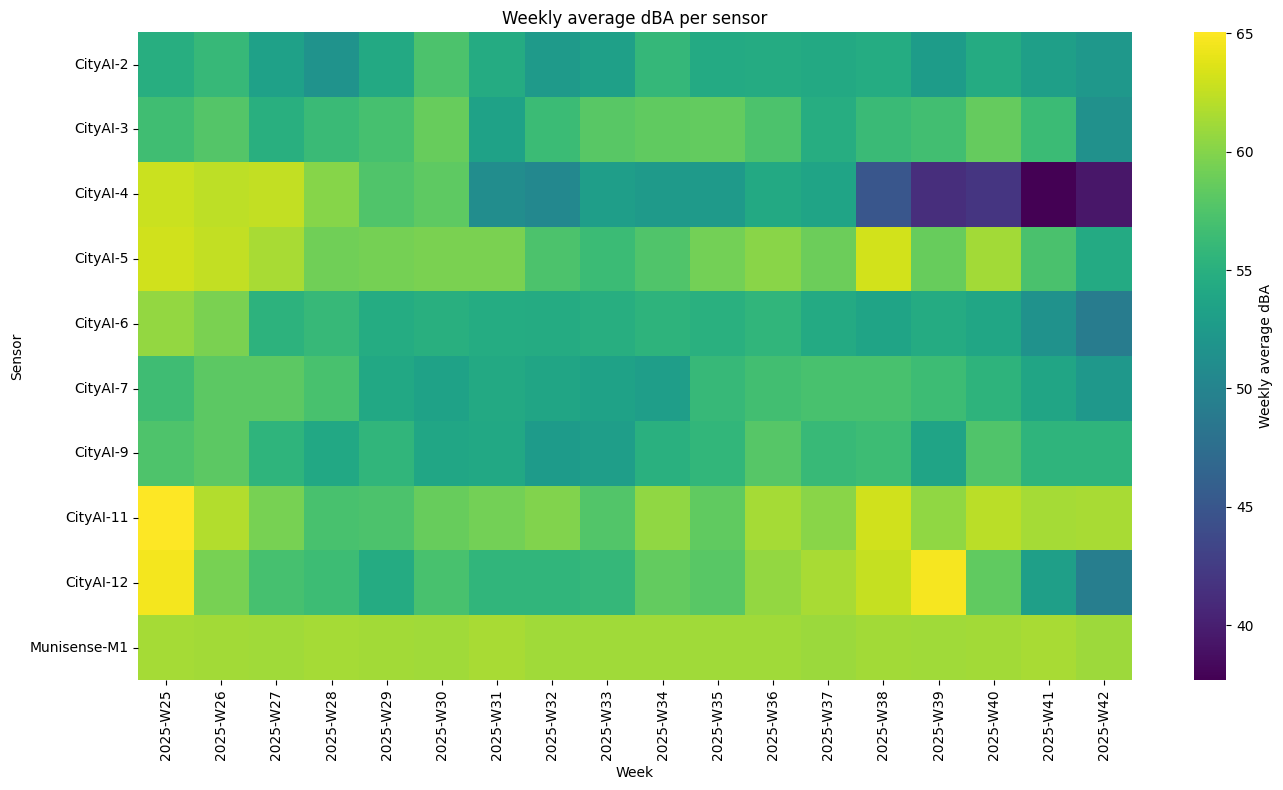

In [9]:
def weekly_dba_pivot(df, sensor_type, value_col="dba"):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    iso = df["datetime"].dt.isocalendar()
    df["year_week"] = iso["year"].astype(str) + "-W" + iso["week"].astype(str).str.zfill(2)

    pivot = df.pivot_table(
        values=value_col,
        index="sensor",
        columns="year_week",
        aggfunc="mean"
    )

    pivot.index = [f"{sensor_type}-{display_sensor(s)}" for s in pivot.index]
    return pivot

pivot_cityai = weekly_dba_pivot(df_CityAI, "CityAI")
pivot_munisense = weekly_dba_pivot(df_Munisense, "Munisense")

combined = pd.concat([pivot_cityai, pivot_munisense])
combined = combined[sorted(combined.columns)]  # re-sort after concat

plt.figure(figsize=(14, 8))
sns.heatmap(combined, cmap="viridis", cbar_kws={"label": "Weekly average dBA"})
plt.title("Weekly average dBA per sensor")
plt.xlabel("Week")
plt.ylabel("Sensor")
plt.tight_layout()
plt.show()

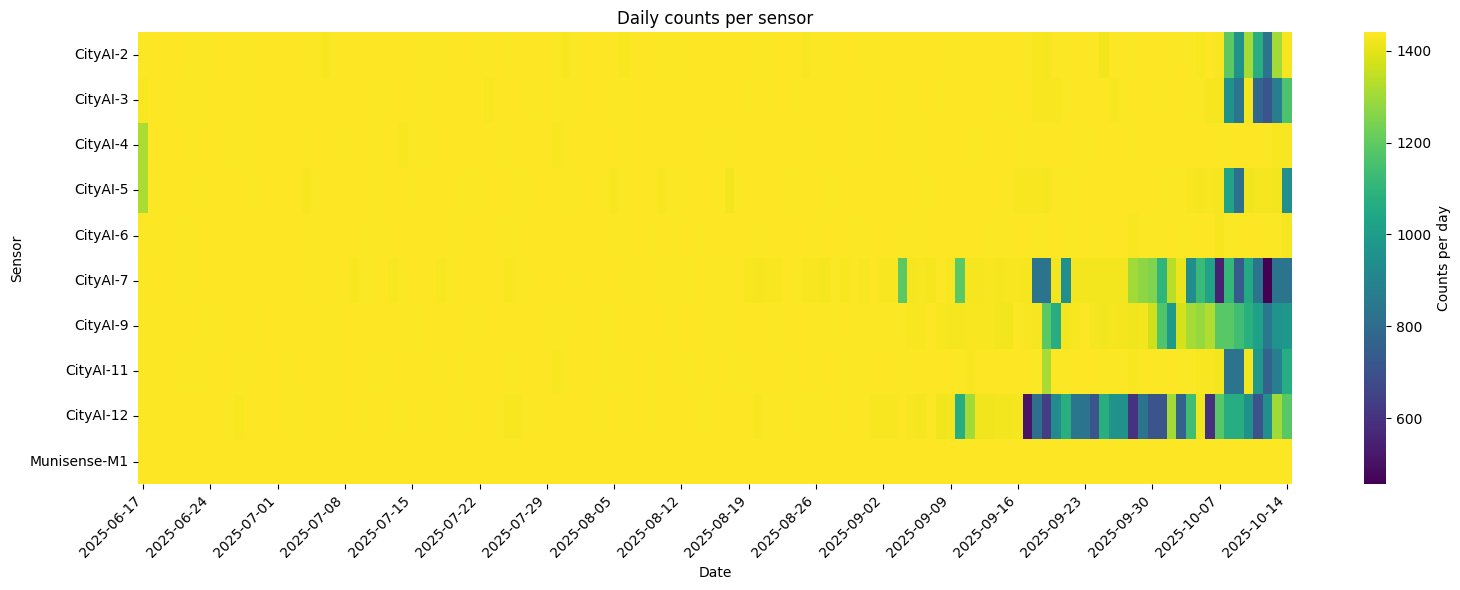

In [10]:
def daily_completeness_pivot(df, sensor_type):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["date"] = df["datetime"].dt.normalize()

    daily_counts = df.groupby(["sensor", "date"]).size().reset_index(name="n_readings")

    pivot = daily_counts.pivot_table(
        values="n_readings",
        index="sensor",
        columns="date",
        fill_value=0  # explicitly show missing days as 0 instead of Nan
    )

    pivot.index = [f"{sensor_type}-{display_sensor(s)}" for s in pivot.index]
    return pivot

pivot_cityai = daily_completeness_pivot(df_CityAI, "CityAI")
pivot_munisense = daily_completeness_pivot(df_Munisense, "Munisense")

combined = pd.concat([pivot_cityai, pivot_munisense])
combined = combined[sorted(combined.columns)]

plt.figure(figsize=(16, 6))
ax = sns.heatmap(combined, cmap="viridis", cbar_kws={"label": "Counts per day"}, xticklabels=7)
tick_positions = ax.get_xticks()
ax.set_xticklabels([combined.columns[int(pos)].strftime('%Y-%m-%d') for pos in tick_positions], rotation=45, ha='right')
plt.title("Daily counts per sensor")
plt.xlabel("Date")
plt.ylabel("Sensor")
plt.tight_layout()
plt.show()

### Statistical Analysis

In [11]:
import numpy as np

def to_linear(db):
    return 10 ** (db / 10)

def to_db(linear):
    return 10 * np.log10(linear)

def sensor_statistics(df, col="dba"):
    sensors = df["sensor"].unique()
    results = []

    for sensor in sensors:
        sensor_df = df[df["sensor"] == sensor]
        values = sensor_df[col].dropna()

        linear = to_linear(values)

        results.append({
            "sensor": sensor,
            "count": values.count(),
            "mean_leq": to_db(linear.mean()),
            "std_db": values.std(),
            "min": values.min(),
            "25%": values.quantile(0.25),
            "50%": values.quantile(0.50),
            "75%": values.quantile(0.75),
            "max": values.max()
        })

    return pd.DataFrame(results)

sensor_statistics(df_CityAI)

,sensor,count,mean_leq,std_db,min,25%,50%,75%,max
0,2,170493,67.834531,8.954188,35.028760,47.178748,53.679370,60.326447,98.052536
1,3,169115,69.107038,10.030309,35.021968,48.907979,56.075917,63.600719,93.593183
2,4,172360,70.919046,11.978127,32.192391,42.886010,50.714072,59.940046,93.313956
3,5,170703,76.150375,11.398609,36.050470,50.560331,58.610674,66.920043,102.377550
4,6,172473,68.145286,9.410351,35.330727,47.328708,54.498115,61.890121,96.330145
5,7,162675,70.654923,11.348642,31.840752,46.293951,55.202059,64.142659,98.866576
6,9,167310,70.944522,11.870323,31.234044,45.535532,54.990111,64.308292,98.069902
7,11,168956,75.301537,12.656682,33.453602,49.831106,59.761242,69.746984,96.937475
8,12,157357,72.252049,11.907443,32.532174,48.508865,57.404637,66.748968,94.791251


In [12]:
sensor_statistics(df_Munisense)

,sensor,count,mean_leq,std_db,min,25%,50%,75%,max
0,45,172800,79.158502,16.841732,32.10014,46.660167,61.135359,75.826795,90.499985


In [13]:
def range_check(df, sensor_type, value_col="dba", low=30, high=80):
    below = df.groupby("sensor")[value_col].apply(lambda x: (x < low).sum())
    above = df.groupby("sensor")[value_col].apply(lambda x: (x > high).sum())

    result = pd.DataFrame({
        "below_threshold": below,
        "above_threshold": above
    })
    result.index = [f"{sensor_type}-{s}" for s in result.index]
    return result

range_cityai = range_check(df_CityAI, "CityAI")
range_munisense = range_check(df_Munisense, "Munisense")

combined = pd.concat([range_cityai, range_munisense])
combined

,below_threshold,above_threshold
CityAI-2,0,1257
CityAI-3,0,2486
CityAI-4,0,4724
CityAI-5,0,9422
CityAI-6,0,959
CityAI-7,0,2756
CityAI-9,0,2673
CityAI-11,0,11070
CityAI-12,0,6453
Munisense-45,0,30885


In [14]:
df_CityAI['datetime'] = pd.to_datetime(df_CityAI['datetime'])

results = []
for sensor in sorted(df_CityAI['sensor'].unique()):
    sdata = df_CityAI[df_CityAI.sensor == sensor].copy()
    sdata['date'] = sdata['datetime'].dt.normalize()
    daily = sdata.groupby('date').size()

    before = daily.loc[:'2025-06-30']
    after = daily.loc['2025-07-01':]

    results.append({
        'sensor': sensor,
        'total_readings': len(sdata),
        'first_date': sdata['datetime'].min(),
        'last_date': sdata['datetime'].max(),
        'mean_before_jul1': before.mean() if len(before) else None,
        'days_before_jul1': len(before),
        'mean_after_jul1': after.mean() if len(after) else None,
        'days_after_jul1': len(after),
    })

summary = pd.DataFrame(results)
print(summary.to_string())

   sensor  total_readings          first_date           last_date  mean_before_jul1  days_before_jul1  mean_after_jul1  days_after_jul1
0       2          170493 2025-06-17 00:00:00 2025-10-14 23:59:00       1437.500000                14      1418.566038              106
1       3          169115 2025-06-17 00:00:00 2025-10-14 23:59:00       1436.785714                14      1405.660377              106
2       4          172360 2025-06-17 01:59:00 2025-10-14 23:58:00       1428.785714                14      1437.330189              106
3       5          170703 2025-06-17 01:59:00 2025-10-14 23:59:00       1428.785714                14      1421.698113              106
4       6          172473 2025-06-17 00:00:00 2025-10-14 23:59:00       1437.642857                14      1437.226415              106
5       7          162675 2025-06-17 00:00:00 2025-10-14 23:59:00       1437.714286                14      1344.783019              106
6       9          167310 2025-06-17 00:00:00 20

Exceedance

In [15]:
site_map_cityai = {
    2: 'Demolition', 3: 'Demolition',
    4: 'Construction', 5: 'Construction', 6: 'Construction',
    7: 'Renovation', 9: 'Renovation',
    11: 'Infrastructure', 12: 'Infrastructure'
}
site_map_munisense = {
    45: 'Demolition',
    48: 'Infrastructure'
}

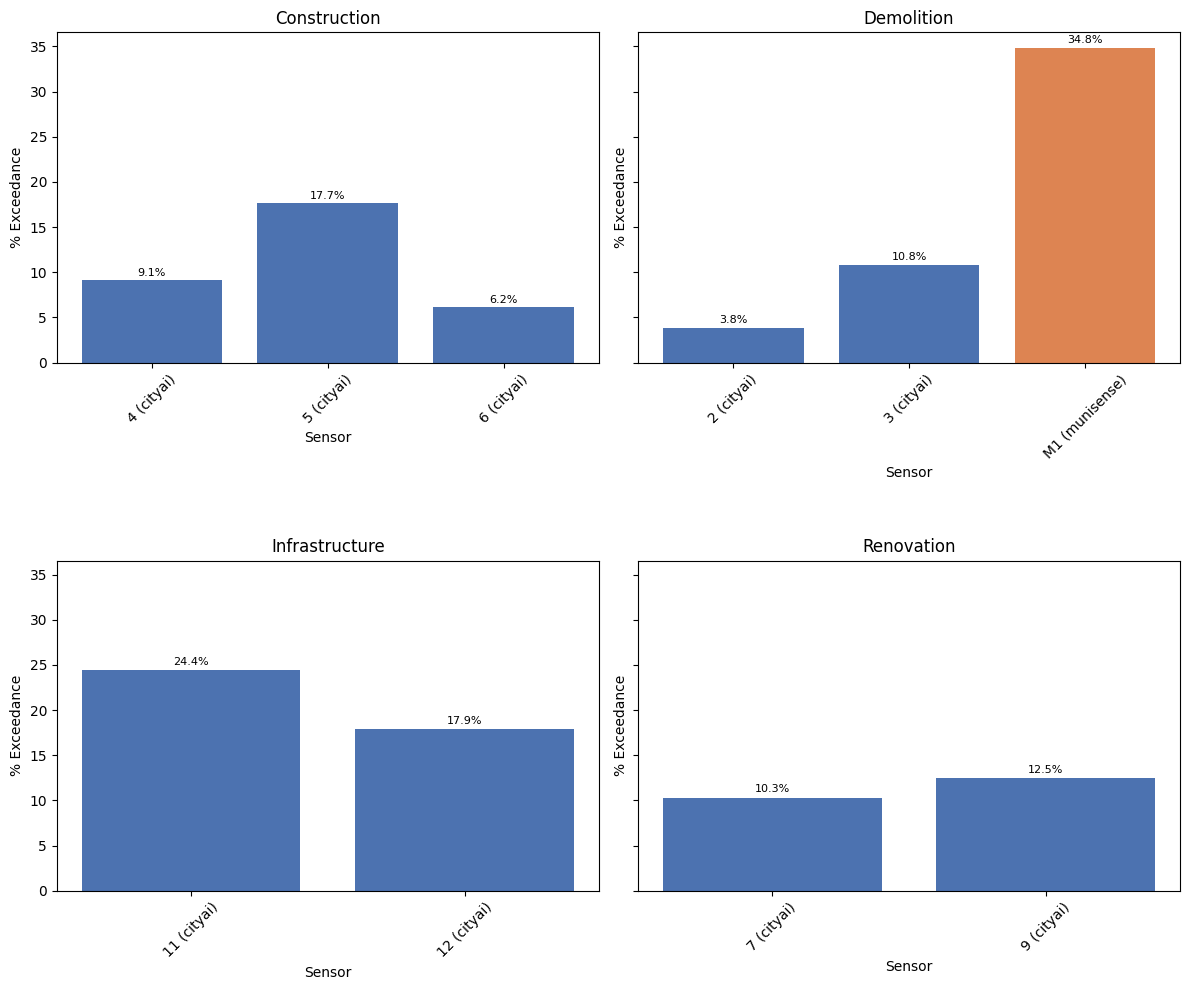

In [16]:
df_CityAI['site'] = df_CityAI.sensor.map(site_map_cityai)
df_Munisense['site'] = df_Munisense.sensor.map(site_map_munisense)

df_CityAI['source'] = 'cityai'
df_Munisense['source'] = 'munisense'

# --- combine ---
combined = pd.concat([df_CityAI, df_Munisense], ignore_index=True)

# --- placeholder, swap in the real value later ---
LEGAL_LIMIT = 70
COL = 'dba'  # or 'avg_spla'

# --- exceedance flagging + summary ---
def flag_exceedances(df, limit, col='dba'):
    df = df.copy()
    df['exceeds'] = df[col] > limit
    return df

def exceedance_summary(df, limit, col='dba'):
    df = flag_exceedances(df, limit, col)
    summary = (
        df.groupby(['site', 'source', 'sensor'])['exceeds']
        .agg(n_exceedances='sum', n_total='count')
    )
    summary['pct_exceedance'] = summary.n_exceedances / summary.n_total * 100
    return summary.reset_index()

summary = exceedance_summary(combined, LEGAL_LIMIT, COL)

# --- plot: grouped bar chart, one subplot per site ---
sites = summary['site'].dropna().unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()

colors = {'cityai': '#4C72B0', 'munisense': '#DD8452'}

for ax, site in zip(axes, summary['site'].dropna().unique()):
    site_data = summary[summary.site == site]
    x_labels = site_data['sensor'].map(display_sensor).astype(str) + " (" + site_data['source'] + ")"
    bar_colors = site_data['source'].map(colors)
    bars = ax.bar(x_labels, site_data['pct_exceedance'], color=bar_colors)

    for bar, pct in zip(bars, site_data['pct_exceedance']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ax.get_ylim()[1] * 0.01,
            f'{pct:.1f}%',
            ha='center', va='bottom', color='black', fontsize=8
        )

    ax.set_title(site)
    ax.set_xlabel('Sensor')
    ax.set_ylabel('% Exceedance')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()
#plt.savefig('exceedance_by_site.png', dpi=150)

#### Observations
1. Infrastructure and Renovation have most exceedences
2. Some sensors pick up a lot more exceedences, why? Distance to site, wind?
3. Munisense picks up very little, but so do some CityAI, is this a sign of quality or underperformance?

Other stuff

In [17]:
def site_statistics(df, site_map, col="avg_spla", exclude_sources=None):
    df = df.copy()
    df["site"] = df["sensor"].map(site_map)
    df = df.dropna(subset=["site"])

    if exclude_sources:
        df = df[~df["source"].isin(exclude_sources)]

    results = []
    for site, group in df.groupby("site"):
        values = group[col].dropna()

        results.append({
            "site": site,
            "count": values.count(),
            "mean_leq": to_db(values.mean()),
            "std_db": to_db(values).std(),
            "min": to_db(values).min(),
            "25%": to_db(values).quantile(0.25),
            "50%": to_db(values).quantile(0.50),
            "75%": to_db(values).quantile(0.75),
            "max": to_db(values).max()
        })

    return pd.DataFrame(results)

# All sites, both sources (as before)
site_stats_all = site_statistics(combined, {**site_map_cityai, **site_map_munisense})

# Demolition only, CityAI vs. Demolition excluding Munisense
demolition_data = combined[combined["site"] == "Demolition"]

demolition_cityai_only = site_statistics(
    demolition_data, {**site_map_cityai, **site_map_munisense},
    exclude_sources=["munisense"]
)
demolition_cityai_only["site"] = "Demolition (CityAI only)"

# Combine into one comparison table
comparison = pd.concat([
    site_stats_all[site_stats_all["site"] != "Demolition"],
    site_stats_all[site_stats_all["site"] == "Demolition"],
    demolition_cityai_only
], ignore_index=True)

comparison

,site,count,mean_leq,std_db,min,25%,50%,75%,max
0,Construction,515536,73.001690,11.369394,32.192391,46.815730,54.694764,63.178360,102.377550
1,Infrastructure,326313,74.090892,12.345201,32.532174,49.147936,58.563589,68.341669,96.937475
2,Renovation,329985,70.804169,11.616315,31.234044,45.923831,55.095846,64.225784,98.866576
3,Demolition,512408,75.117609,12.812511,32.100140,47.719693,56.034449,65.182588,98.052536
4,Demolition (CityAI only),339608,68.514661,9.595442,35.021968,47.990615,54.800441,61.877682,98.052536


In [18]:
df_CityAI['date'] = df_CityAI['datetime'].dt.normalize()

completeness = (
    df_CityAI.groupby(['sensor', 'date'])
    .size()
    .reset_index(name='n_readings')
    .groupby('sensor')['n_readings']
    .agg(mean_readings='mean', median_readings='median', min_readings='min', max_readings='max', n_days='count')
    .reset_index()
)

completeness['pct_complete'] = completeness['mean_readings'] / 1440 * 100

print(completeness.to_string())

   sensor  mean_readings  median_readings  min_readings  max_readings  n_days  pct_complete
0       2    1420.775000           1438.0           830          1440     120     98.664931
1       3    1409.291667           1437.0           712          1440     120     97.867477
2       4    1436.333333           1438.0          1316          1440     120     99.745370
3       5    1422.525000           1437.0           817          1440     120     98.786458
4       6    1437.275000           1437.5          1427          1440     120     99.810764
5       7    1355.625000           1434.0           456          1440     120     94.140625
6       9    1394.250000           1436.0           849          1440     120     96.822917
7      11    1407.966667           1437.0           760          1440     120     97.775463
8      12    1311.308333           1435.0           506          1440     120     91.063079
